In [1]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [2]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data()

(["Measles", "Mumps", "Rubella", "Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib", "Polio", "HPV", "Rotavirus", "PCV"], ["M", "MR", "MMR", "TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa", "HPV", "Rotavirus", "PCV"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "Td" => ["Diphtheria", "Tetanus"], "PCV" => ["PCV"], "Rotavirus" => ["Rotavirus"], "DTwP-Hib" => ["Diphtheria", "Tetanus", "Pertussis", "Hib"], "IPV" => ["Polio"], "Hexa" => ["Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib", "Polio"], "TT" => ["Tetanus"], "HPV" => ["HPV"], "MR" => ["Measles", "Rubella"]…), ["AJ_Vaccines", "BB_NCIPD", "China_National", "Bharat_Biotech", "Bilthoven", "Biological_E", "GSK", "Haffkine_Bio", "LG_Chem", "Merck_Sharp", "Panacea_Biotec", "PT_Bio", "Sanofi", "Serum_Institute", "Pfizer"], Dict("MMR" => ["Serum_Institute", "GSK"], "Td" => ["Serum_Institute", "PT_Bio", "BB_NCIPD", "Biological_E"], "PCV" => ["Serum_Institute", "GSK", "Pfizer"], "Rotavir

In [3]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

(Any[("Measles", 1, 3), ("Mumps", 1, 3), ("Rubella", 1, 3), ("Diphtheria", 1, 1), ("Tetanus", 1, 1), ("Pertussis", 1, 1), ("Hib", 1, 1), ("Hepatitis_B", 1, 1), ("Polio", 1, 1), ("HPV", 1, 5), ("Rotavirus", 1, 1), ("PCV", 1, 3)], Any[("Penta", 398056.0), ("OPV", 27969.0), ("IPV", 410128.0), ("PCV", 590380.0), ("M", 280764.0), ("MR", 879375.0), ("MMR", 83172.0), ("TT", 7683.0), ("HepB", 3279.0), ("Hib", 2829.0), ("DT", 116834.0), ("Td", 5299.0), ("DTwP", 30290.0), ("DTwP-Hib", 43272.0), ("Hexa", 86544.0), ("HPV", 242286.0), ("Rotavirus", 156727.0)], Any[("Diphtheria", 0.0), ("Hib", 0.0), ("Measles", 0.0), ("Mumps", 0.0), ("PCV", 0.0), ("Pertussis", 0.0), ("Polio", 0.0), ("Rotavirus", 0.0), ("Rubella", 0.0), ("Tetanus", 0.0), ("Hepatitis_B", 0.0), ("HPV", 0.0)])

In [4]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Sanofi" => 87429.0, "Pfizer" => 83917.0, "AJ_Vaccines" => 7711.0, "Serum_Institute" => 587114.0, "China_National" => 12812.0, "BB_NCIPD" => 39224.0, "Merck_Sharp" => 56991.0, "Bilthoven" => 12048.0, "Haffkine_Bio" => 80973.0, "Biological_E" => 164886.0…), Dict{Any, Any}(("PCV", "Serum_Institute", 6) => 2.29375, ("Rotavirus", "Bharat_Biotech", 2) => 0.9874999999999999, ("Rotavirus", "Serum_Institute", 2) => 0.9, ("Rotavirus", "Serum_Institute", 3) => 0.9, ("PCV", "GSK", 10) => 2.950390625, ("Rotavirus", "Bharat_Biotech", 10) => 0.9249999999999999, ("IPV", "Bilthoven", 5) => 1.9058333333333335, ("Rotavirus", "GSK", 10) => 2.1732915, ("DT", "BB_NCIPD", 3) => 0.175, ("OPV", "Serum_Institute", 9) => 0.13…), Dict{Any, Any}(("Hib", 5) => 0.11800000000000001, ("DT", 10) => 0.16999999999999998, ("Td", 3) => 0.11737500000000001, ("MMR", 6) => 3.3694166666666665, ("Hexa", 3) => 4.7, ("PCV", 5) =

In [19]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios, p_ω_MVP, Ω_MVP = process_scenario_data_n_selected_with_MVP(current_directory, data_dir, 3, 3, A, T, P, 1, 10, 5, 1, 1, 1, 1, false, 1)

(Dict("Partial_1" => [7], "All" => [8, 1, 29, 35, 9, 7, 14, 6, 5], "Partial_2" => [8, 1, 29, 35, 9, 14, 6, 5]), Dict(5 => 0.025618016356978218, 29 => 0.0001536273958561518, 35 => 0.0007284057562145128, 7 => 0.0018816819956863726, 6 => 0.019499295292086764, 9 => 0.00045823343936403897, 8 => 0.0020084274150849366, 14 => 0.000836891719906036, 1 => 0.9488154206288231), Dict(5 => 0.025666312194530333, 29 => 0.00015391701873914297, 35 => 0.0007297789681597295, 6 => 0.019536055936809783, 9 => 0.0004590973145150299, 8 => 0.0020122137614914074, 14 => 0.0008384694527792637, 1 => 0.9506041553529754), [7], [8, 1, 29, 35, 9, 14, 6, 5], 7, Dict{Any, Any}(("Pfizer", 2, 35) => 83917.0, ("AJ_Vaccines", 8, 29) => 7711.0, ("China_National", 9, 8) => 12812.0, ("Bharat_Biotech", 9, 35) => 59303.0, ("Sanofi", 2, 6) => 87429.0, ("Biological_E", 1, 14) => 164886.0, ("PT_Bio", 2, 7) => 45912.0, ("Serum_Institute", 10, 29) => 587114.0, ("AJ_Vaccines", 6, 14) => 7248.0, ("Pfizer", 4, 1) => 83917.0…), Dict{Any, A

In [28]:
p_ω_test_partial_2

Dict{Int64, Float64} with 8 entries:
  5  => 0.0256663
  29 => 0.000153917
  35 => 0.000729779
  6  => 0.0195361
  9  => 0.000459097
  8  => 0.00201221
  14 => 0.000838469
  1  => 0.950604

In [5]:
gurobi_solver = JuMP.optimizer_with_attributes(Gurobi.Optimizer, "FeasibilityTol" => 1e-3, "OutputFlag" => 0, "Presolve" => 0, "NumericFocus" => 1, "Heuristics" => 0.5, "PumpPasses" => 10, "GomoryPasses"=>2)
Masterproblem = JuMP.Model()
JuMP.set_optimizer(Masterproblem, gurobi_solver)


 @variable(Masterproblem, 0.0 <= F[a in A, (t, tau) in F_time_set] <= 1.0, Bin)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-04
Set parameter FeasibilityTol to value 0.001


2-dimensional DenseAxisArray{VariableRef,2,...} with index sets:
    Dimension 1, ["Measles", "Mumps", "Rubella"]
    Dimension 2, Any[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6)  …  (7, 7), (7, 8), (7, 9), (7, 10), (8, 8), (8, 9), (8, 10), (9, 9), (9, 10), (10, 10)]
And data, a 3×40 Matrix{VariableRef}:
 F[Measles,(1, 1)]  F[Measles,(1, 2)]  …  F[Measles,(10, 10)]
 F[Mumps,(1, 1)]    F[Mumps,(1, 2)]       F[Mumps,(10, 10)]
 F[Rubella,(1, 1)]  F[Rubella,(1, 2)]     F[Rubella,(10, 10)]

In [6]:
num_vars = JuMP.num_variables(Masterproblem)


120

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [10]:
# single cut
new_updated_data = {"lb":[2.1572551573089007e6,2.1746045004171003e6,2.1746045004171026e6,2.1813450419043866e6,2.181345041904387e6,2.228898153531793e6,2.228898153531794e6,2.2288981535317944e6,2.2288981535317954e6,2.2288981535317963e6,2.228898153531797e6,2.228898153531798e6,2.228898153531799e6,2.2288981535318e6,2.2288981535318005e6,2.2288981535318014e6,2.228898153531802e6,2.2288981535318024e6,2.2288981535318033e6,2.228898153531804e6,2.228898153531805e6,2.228898153531806e6,2.2288981535318065e6,2.2288981535318075e6,2.2288981535318075e6,2.2288981535318084e6,2.2288981535318093e6,2.22889815353181e6,2.2288981535318103e6,2.2288981535318103e6,2.228898153531811e6,2.2288981535318117e6,2.228898153531812e6,2.228898153531813e6,2.228898153531814e6,2.2385173587358464e6,2.238517358735847e6,2.251258609774961e6,2.2512586097749616e6,2.251258609774961e6,2.251258609774962e6,2.251258609774963e6,2.251258609774964e6,2.251258609774965e6,2.2731145477165193e6,2.2731145477165203e6,2.2731145477165217e6,2.2731145477165226e6,2.2731145477165235e6,2.2731145477165245e6,2.273114547716525e6,2.273114547716525e6,2.2731145477165254e6,2.2731145477165263e6,2.273114547716527e6,2.2731145477165277e6,2.2731145477165286e6,2.2731145477165296e6,2.27311454771653e6,2.273114547716531e6,2.2731145477165314e6,2.2731145477165324e6,2.2731145477165333e6,2.2731145477165338e6,2.273114547716534e6,2.2731145477165347e6,2.273114547716535e6,2.273114547716536e6,2.273114547716536e6,2.273114547716537e6,2.2731145477165375e6,2.2731145477165384e6,2.273114547716539e6,2.2731145477165394e6,2.27311454771654e6,2.2731145477165408e6,2.2731145477164406e6,2.2731145477165417e6,2.2731145477165426e6,2.273114547716543e6,2.2731145477165435e6,2.2731145477165445e6,2.2731145477165454e6,2.2731145477165454e6,2.294927799881675e6,2.2949277998816753e6,2.2949277998816767e6,2.2949277998816776e6,2.294927799881678e6,2.294927799881679e6,2.2949277998816795e6],"ub":[1.7549724580955453e9,1.754916874786495e9,1.754916874786495e9,1.754916874786495e9,1.754916874786495e9,1.754916874786495e9,1.754916874786495e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7549077629622312e9,1.7547822629159114e9,1.7547822629159114e9,1.7547822629159114e9,1.7547822629159114e9,1.7540666244394135e9,1.7540666244394135e9,1.7540666244394135e9,1.7540666244394135e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9,1.7521231160787904e9]}

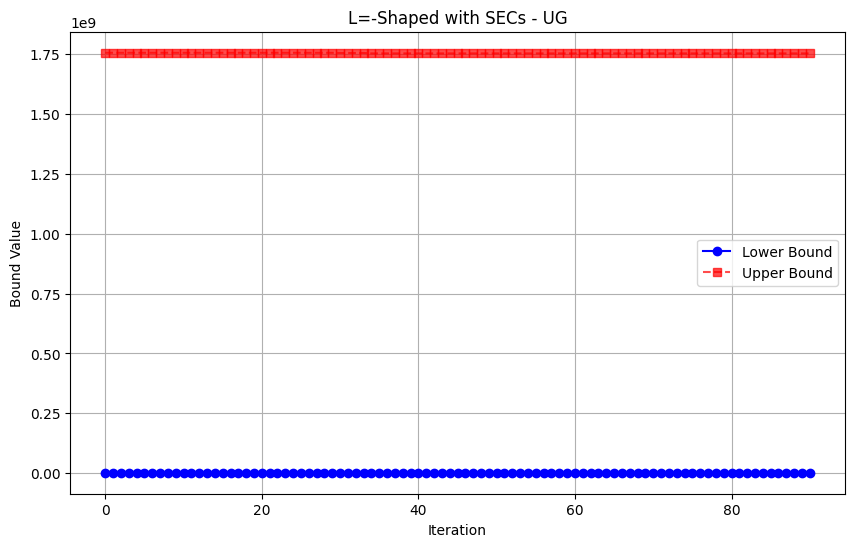

In [11]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
# Plot lower and upper bounds
plt.plot(new_updated_data["lb"], label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(new_updated_data["ub"], label="Upper Bound", marker="s", linestyle="--", color="red", alpha=0.7)
# 
# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("L=-Shaped with SECs - UG")
plt.legend()
plt.grid(True)
# plt.savefig("UG_L_shaped_trust_region.pdf")
# Show the plot
plt.show()


In [ ]:
            if iter2 >= 2
                println("Generating trust region cuts")
                # F variable
                try
                    unregister(Masterproblem, :trust_region_constr_all)
                catch e
                    println("No constraint: ", e)
                finally
                    trust_expr_F = sum(
                        F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
                                                  Masterproblem[:F][a, (t, tau)]
                        for a in A, (t, tau) in F_time_set
                    )

                    trust_expr_Y = sum(
                            Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
                            for p in P, t in T
                        )

                    trust_expr_L = sum(
                        L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
                        for p in P, t in T
                    )

                    trust_expr_Z = sum(
                            Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
                            for v in V, p in P_v[v], t in T, m in keys(m_segments)
                        )

                    trust_expr_all = trust_expr_F + trust_expr_Y + trust_expr_L + trust_expr_Z
                    @constraint(Masterproblem, trust_region_constr_all, trust_expr_all <= trust_delta_F)
                end
            end

In [ ]:
            # # add solution elimination constraints (Masterproblem, iter, Z_M, Z_M_prev) - create a function for this - MULTIPLE TRUST REGIONS FOR EACH BINARY
            # if iter2 == 1
            #     trust_delta_F = max_horizon_length * max_tender_length * length(A)/ 2
            #     trust_delta_Y = length(P) * length(T) / 2
            #     trust_delta_L = length(P) * length(T) / 2
            #     trust_delta_Z = length(V) * length(P) * length(T) * length(m_segments) /2
            # elseif iter2 >= 2
            #     if Z_M >= Z_M_prev
            #         trust_delta_F = ceil(1.3*trust_delta_F)
            #         trust_delta_Y = ceil(1.3*trust_delta_Y)
            #         trust_delta_L = ceil(1.3*trust_delta_L)
            #         trust_delta_Z = ceil(1.3*trust_delta_Z)
            #     else
            #         trust_delta_F = ceil(0.6*trust_delta_F)
            #         trust_delta_Y = ceil(0.6*trust_delta_Y)
            #         trust_delta_L = ceil(0.6*trust_delta_L)
            #         trust_delta_Z = ceil(0.6*trust_delta_Z)
            #     end
            # end

            # println("Current F trust region RHS: $trust_delta_F")
            # println("Current Y trust region RHS: $trust_delta_Y")
            # println("Current L trust region RHS: $trust_delta_L")
            # println("Current Z trust region RHS: $trust_delta_Z")

            # if iter2 >= 2
            #     println("Generating trust region cuts")
            #     # F variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_F)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         trust_expr = sum(
            #             F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
            #                                       Masterproblem[:F][a, (t, tau)]
            #             for a in A, (t, tau) in F_time_set
            #         )
            #         @constraint(Masterproblem, trust_region_constr_F, trust_expr <= trust_delta_F)
            #     end

            #     # Y variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Y)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Y,
            #             sum(
            #                 Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
            #                 for p in P, t in T
            #             ) <= trust_delta_Y)
            #     end
                

            #     # L variable

            #     try
            #         unregister(Masterproblem, :trust_region_constr_L)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_L,
            #         sum(
            #             L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
            #             for p in P, t in T
            #         ) <= trust_delta_L)
            #     end
            
            #     # # Z variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Z)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Z,
            #             sum(
            #                 Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
            #                 for v in V, p in P_v[v], t in T, m in keys(m_segments)
            #             ) <= trust_delta_Z)
            #     end
            # end #end iter generation of trust region cuts   